In [97]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

df = pd.read_pickle("Data/Export 270426/data_long.pkl")

Measure MRPK and MRPL for every firm
$$
 \text{MRPK}_{ist} :=
    \left(\frac{\alpha}{\mu}\right)
    \left(\frac{p_{ist} y_{ist}}{k_{ist}}\right)
    = \left(\frac{1 + \tau^{k}_{ist}}{1 - \tau^{y}_{ist}}\right)
    (r_t + \delta_{st})
$$

$$
 \text{MRPL}_{ist} :=
    \left(\frac{1-\alpha}{\mu}\right)
    \left(\frac{p_{ist} y_{ist}}{\ell_{ist}}\right)
    = \left(\frac{1}{1 - \tau^{y}_{ist}}\right) w_{st}
$$

$$ 
TFPR_{ist} = p_{ist} A_{ist} = \frac{p_{ist} y_{ist}}{k_{ist}^\alpha l_{ist}^{1-\alpha}}
$$

In [98]:
alpha = 0.35
markup = 1

# see gopinath p. 1926
#calculate mrpk
df['MRPK'] = (alpha/markup) * (df['nvad']/ df['k'])
#calculate mrpl
df['MRPL'] = ((1-alpha)/markup)* (df['nvad']/ df['l'])
#calculate firms total factor productivity
df['TFPR'] = df['revenue'] / ( (df['k']** alpha) * (df['l']**(1-alpha)) )

calculate the weights per sector $\omega_s$ is defined as:
$$
    \omega_s = \frac{1}{T}\sum_{t=1}^{T}
    \frac{\text{VA}_{st}}{\text{VA}_{t}}
$$
with $\text{VA}_{st}$ denoting value added of industry $s$
at time $t$, and $\text{VA}_{t}$ total manufacturing value
added.

In [99]:
#calculate weights per sector and year
vast = df.groupby(['sector', 'year'])['nvad'].sum().reset_index()
vat = df.groupby(['year'])['nvad'].sum().reset_index().rename(columns = {'nvad':'nvadt'})
#merge on years
vast = pd.merge(vast, vat, how='left', on='year')

#divide sectoral vad with total va per year and take mean for every sector
vast['sectorshare'] = vast['nvad'] / vast['nvadt']
weights = vast.groupby('sector')['sectorshare'].mean().reset_index().rename(columns={'sectorshare': 'sectorweight'})
print("check if weights sum to 1: ", round(weights.sectorweight.sum()))
weights

check if weights sum to 1:  1


,sector,sectorweight
0,1011,0.012362
1,1012,0.001012
2,1013,0.023235
3,1020,0.008122
4,1031,0.000856
...,...,...
225,3315,0.003633
226,3316,0.001004
227,3317,0.001009
228,3319,0.000867


For every 4 digit level sector take the standard deviation per year in MRPK
$$
 \Delta_{st} = \text{Standard Deviation}\left(\log(\{x_{ist}\}_{i=1}^{N_{st}})\right)
$$

For each year $t$,
aggregate across industries using time-invariant weights
$\omega_s$:
$$
    \Delta_t = \sum_{s} \omega_s \, \Delta_{st}
$$

In [100]:
#winsorize function to drop the stupid ones
def winsorise(s, lower=0.1, upper=0.9):
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)

In [101]:
#calcualte dispersion from log MRPK and MRPL
df['log_MRPK'] = np.log(df['MRPK'])
df['log_MRPL'] = np.log(df['MRPL'])
df['log_TFPR'] = np.log(df['TFPR'])

for var in ['log_MRPK', 'log_MRPL', 'log_TFPR']:
    df[var] = df.groupby(['sector', 'year'])[var].transform(winsorise)

#group by sector, year and take std
disp = df.groupby(['sector', 'year']).agg(
                    disp_MRPK=('log_MRPK', 'std'),
                    disp_MRPL=('log_MRPL', 'std'),
                    disp_TFPR=('log_TFPR', 'std')).reset_index()

#merge weights with dispersion on sector and sum
disp = pd.merge(disp, weights, on='sector', how='left')
disp['w_disp_MRPK'] = disp['disp_MRPK'] * disp['sectorweight']
disp['w_disp_MRPL'] = disp['disp_MRPL'] * disp['sectorweight']
disp['w_disp_TFPR'] = disp['disp_TFPR'] * disp['sectorweight']
#get dispersion weighted on sectors per year
dispt = disp.groupby('year').agg({'w_disp_MRPK': 'sum', 'w_disp_MRPL': 'sum', 'w_disp_TFPR': 'sum'})
dispt

,w_disp_MRPK,w_disp_MRPL,w_disp_TFPR
year,,,
2015,1.027570,0.351079,0.574700
2016,0.987979,0.337772,0.559697
2017,0.964974,0.339106,0.552031
2018,0.956395,0.338262,0.554025
2019,0.943351,0.324843,0.541551
2020,0.973232,0.359699,0.541829
2021,0.947348,0.343157,0.540741
2022,0.938372,0.359939,0.557589
2023,0.942407,0.344476,0.552041


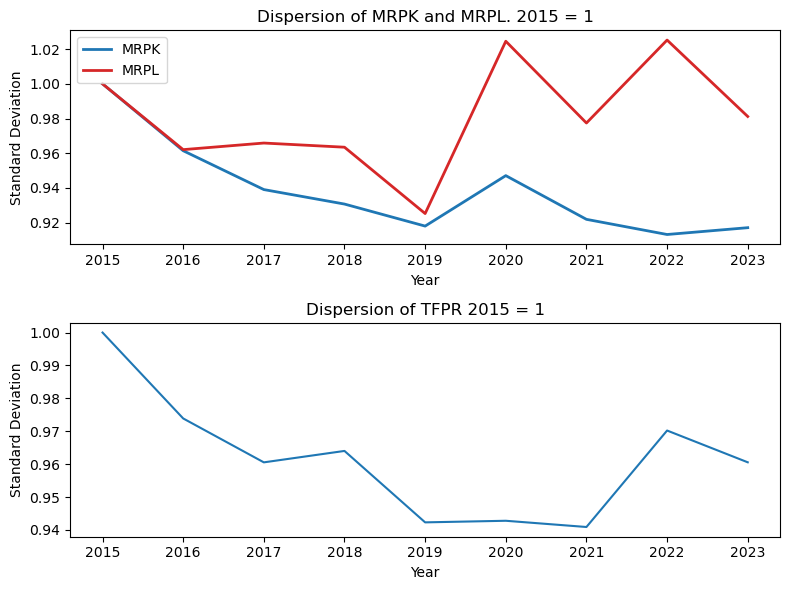

In [102]:
#normalize for start year
START_YEAR = 2015
END_YEAR = 2026

plotdf = dispt[(dispt.index >= START_YEAR) & (dispt.index <= END_YEAR)]
plotdf = plotdf / plotdf.iloc[0]
plotdf = plotdf.reset_index()


#create plot 
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8,6))

ax1.plot(plotdf["year"], plotdf["w_disp_MRPK"], label="MRPK", color="#1f77b4", linewidth=2)
ax1.plot(plotdf["year"], plotdf["w_disp_MRPL"], label="MRPL", color="#d62728", linewidth=2)
ax1.set_title(f"Dispersion of MRPK and MRPL. {plotdf['year'][0]} = 1")
ax1.set_xlabel("Year")
ax1.set_ylabel("Standard Deviation")
ax1.legend()

ax2.plot(plotdf['year'], plotdf['w_disp_TFPR'])
ax2.set_title(f"Dispersion of TFPR {plotdf['year'][0]} = 1")
ax2.set_xlabel("Year")
ax2.set_ylabel("Standard Deviation")


plt.tight_layout()
plt.show()

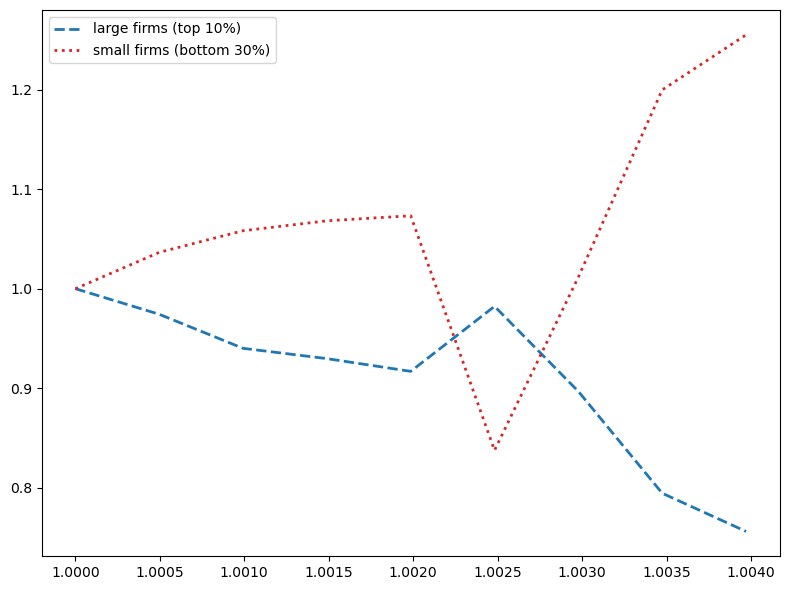

In [103]:
## small versus large firms

# large firms (top 10%)
large = df[df['k'] > df['k'].quantile(0.9)]
large = large.groupby('year').agg(MRPK=('log_MRPK', 'mean')).reset_index()
large = large / large.iloc[0]
large = large.reset_index()


# small firms (bottom 30%)
small = df[df['k'] < df['k'].quantile(0.3)]
small = small.groupby('year').agg(MRPK=('log_MRPK', 'mean')).reset_index()
small = small / small.iloc[0]
small = small.reset_index()


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(large["year"], large["MRPK"], label="large firms (top 10%)", color="#1f77b4", linestyle='--', linewidth=2)
ax.plot(small["year"], small["MRPK"], label="small firms (bottom 30%)", color="#d62728", linestyle=':', linewidth=2)

ax.legend()
plt.tight_layout()
plt.show()





### Efficient level of productivity


$\varepsilon = 3$ from Hsieh and Klenov(2009) \
To find this we need to measure the firms productivity $Z_{ist}$. 

$$
\tilde{Z}_{ist} = \left(\frac{(P_{st}Y_{st})^{-\frac{1}{\varepsilon-1}}}{P_{st}}\right)\left(\frac{(p_{ist}y_{ist})^{\frac{\varepsilon}{\varepsilon-1}}}{k_{ist}^{\alpha}\ell_{ist}^{1-\alpha}}\right)
$$

$$
P_{st}Y_{st} = \sum_i{p_{ist}y_{ist}}
$$

$ P_{st} $ : Price index from eurostat ???

To plot the evolution we measure $ log(TFP) $ and $ log(TFP^e) $ by aggregating the following with the sectorweights.

$$
\log(TFP_{st}) = \log(\sum_i{y_{ist}}) - \alpha \log(K_{st}) - (1-\alpha)\log(L_{st})
$$

$$
\log(TFP^e_{st}) = (\frac{1}{\epsilon - 1})(\log(N_{st}) + \log(\mathbb{E}_i \tilde{Z}_{i s t}^{\varepsilon-1}))
$$

In [104]:
#calculate firm productivity z
EPSILON = 3

#calculate sectorrevenue and merge to df
sectorrevenue = df.groupby(['year', 'sector']).agg(nvad_s = ('nvad', 'sum')).reset_index()
df = df.merge(sectorrevenue, on=['year', 'sector'], how='left')

#calculate firm productivity
df['Z'] = ((df['nvad_s']**(-(1/(EPSILON-1)))) / df['priceind'] ) * ( (df['nvad']**(EPSILON/(EPSILON-1))) / ( (df['k']**alpha) * df['l']**(1-alpha)) )
df['Z_pow'] = df['Z'] ** (EPSILON - 1)

#save df with the measured variables
df.to_pickle('trenddf.pkl')



#df groupby sector and year
sdf = df.groupby(['year', 'sector'])
#calcualte log tfpe and tfp per year and sector by the formulas above
log_tfpe_st =   ((1/(EPSILON-1)) 
             * (np.log(sdf['FirmName'].count()) + np.log(sdf['Z_pow'].mean()) )
            )
log_tfp_st = np.log(sdf['y'].sum()) - alpha * np.log(sdf['k'].sum()) - (1-alpha) * np.log(sdf['l'].sum())
#multiply with the sectorweights and sum to get tfp and tfpe per year
tfp_st_df = pd.concat([log_tfpe_st, log_tfp_st], axis=1)
tfp_st_df.columns = ['log_tfpe_st', 'log_tfp_st']
tfp_st_df = tfp_st_df.reset_index()
tfp_st_df = tfp_st_df.merge(weights, on= 'sector', how='left')
tfp_st_df['wlogtfpe'] = tfp_st_df['log_tfpe_st'] * tfp_st_df['sectorweight']
tfp_st_df['wlogtfp'] = tfp_st_df['log_tfp_st'] * tfp_st_df['sectorweight']
tfp_df = tfp_st_df.groupby('year').agg(log_tfp = ('wlogtfp', 'sum'),
                                       log_tfpe = ('wlogtfpe', 'sum'))
#add a 1% growth tfp
tfp_df['log_tfpg'] = tfp_df['log_tfp'].iloc[0] + np.log(1.01) * np.arange(len(tfp_df))

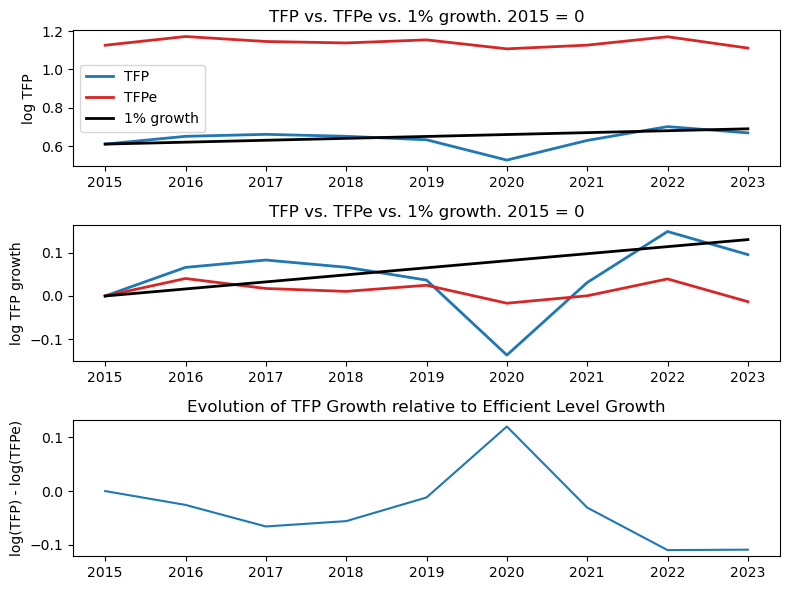

In [105]:
#create plot 
fig, (ax, ax1, ax2) = plt.subplots(nrows=3, ncols=1, figsize=(8,6))

plotdf = tfp_df.copy()
plotdf = plotdf / plotdf.iloc[0] - 1
plotdf = plotdf.reset_index()

ax.plot(tfp_df.index, tfp_df["log_tfp"], label="TFP", color="#1f77b4", linewidth=2)
ax.plot(tfp_df.index, tfp_df["log_tfpe"], label="TFPe", color="#d62728", linewidth=2)
ax.plot(tfp_df.index, tfp_df["log_tfpg"], label="1% growth", color="black", linewidth=2)
ax.set_title(f"TFP vs. TFPe vs. 1% growth. {plotdf['year'][0]} = 0")
ax.set_ylabel("log TFP")
ax.legend()

ax1.plot(plotdf["year"], plotdf["log_tfp"], label="TFP", color="#1f77b4", linewidth=2)
ax1.plot(plotdf["year"], plotdf["log_tfpe"], label="TFPe", color="#d62728", linewidth=2)
ax1.plot(plotdf["year"], plotdf["log_tfpg"], label="1% growth", color="black", linewidth=2)
ax1.set_title(f"TFP vs. TFPe vs. 1% growth. {plotdf['year'][0]} = 0")
ax1.set_ylabel("log TFP growth")
ax.legend()

ax2.plot(plotdf['year'],  plotdf["log_tfpe"] -  plotdf["log_tfp"])
ax2.set_title("Evolution of TFP Growth relative to Efficient Level Growth")
ax2.set_ylabel('log(TFP) - log(TFPe)')



plt.tight_layout()
plt.show()

### log capital moments

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


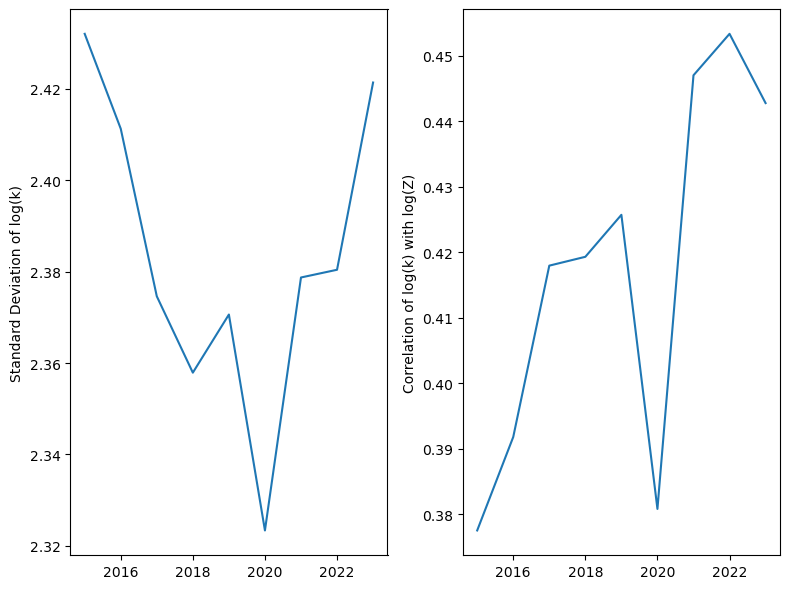

In [106]:
cap = df.copy()

cap['k'] = np.log(cap['k'])
cap['Z'] = np.log(cap['Z'])

capgrp = cap.groupby(['sector', 'year']).agg(
    stdk = ('k', 'std'),
    stdZ = ('Z', 'std')).reset_index()

capcorr = cap.groupby(['sector', 'year']).apply(lambda g: g['k'].corr(g['Z'])).to_frame('correlation').reset_index()

cap = capgrp.merge(capcorr, on=['sector', 'year'], how='inner')

cap = cap.merge(weights, on='sector', how='left')
cap['wstdk'] = cap['stdk'] * cap['sectorweight']
cap['wstdZ'] = cap['stdZ'] * cap['sectorweight']
cap['wcorr'] = cap['correlation'] * cap['sectorweight']

cap = cap.groupby('year').agg(corr = ('wcorr', 'sum'),
                        stdK = ('wstdk', 'sum'))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8,6))

ax1.plot(cap.index, cap['stdK'])
ax1.set_ylabel('Standard Deviation of log(k)')
ax2.plot(cap.index, cap['corr'])
ax2.set_ylabel('Correlation of log(k) with log(Z)')

plt.tight_layout()
plt.show()




### Capital Wedges

Reconsider 

$$
 \text{MRPK}_{ist} :=
    \left(\frac{\alpha}{\mu}\right)
    \left(\frac{p_{ist} y_{ist}}{k_{ist}}\right)
    = \left(\frac{1 + \tau^{k}_{ist}}{1 - \tau^{y}_{ist}}\right)
    (r_t + \delta_{st})
$$

$$
 \text{MRPL}_{ist} :=
    \left(\frac{1-\alpha}{\mu}\right)
    \left(\frac{p_{ist} y_{ist}}{\ell_{ist}}\right)
    = \left(\frac{1}{1 - \tau^{y}_{ist}}\right) w_{st}
$$

We solve this to find the wedges. First via MRPL and then substitute in MRPK

$$
1-\tau_{ist}^y = \frac{w_t}{MRPL_{ist}}
$$

$$
 
1+\tau_{ist}^k = \frac{w_t*MRPK_{ist}}{(r_t + \delta) * MRPL_{ist}}

$$
With logs we have
$$
\log(1+\tau_{ist}^k) = \log w_t + \log MRPK_{ist} - \log(r_t + \delta) - \log MRPL_{ist}
$$


however we simplify the firms problem
$$





In [107]:
#put firms in to sizes based on capital
df['size_quintile'] = df.groupby('year')['k'].transform(
    lambda x: pd.qcut(x, 5, labels=[1,2,3,4,5])
)
#calculate tau k
DELTA = 0.1

df['tau_k'] = ((df['MRPK']) / ((df['realinterestrate'] + 0.1) )) -1

# ── Winsorise tau_k within each year at 10%-90% ───────────────────

# ── Quintile means ───────────────────────────────────────────────
quintile_tau = (df.groupby(['year', 'size_quintile'])['tau_k']
                  .mean()
                  .unstack())
quintile_tau['gap'] = quintile_tau[1] - quintile_tau[5]



/var/folders/wr/9z7nrh5d53gcdr5f5rw1q5vc0000gn/T/ipykernel_40820/2244106562.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_tau = (df.groupby(['year', 'size_quintile'])['tau_k']


In [108]:
print(df.groupby('year')['realinterestrate'].mean())

year
2015    0.0233
2016    0.0169
2017   -0.0044
2018   -0.0028
2019   -0.0014
2020    0.0068
2021   -0.0265
2022   -0.0612
2023    0.0008
Name: realinterestrate, dtype: float64
